In [1]:
import pandas as pd
import scanpy as sc
import numpy as np

from hcrseq.scRNA.analysis import get_repair_df
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from scipy.stats import ranksums

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42


In [2]:
adata = sc.read('../data/P3_clustered.v0.h5ad')

## Figure 6a Plots of repair vs gene expression

In [3]:
timepoint = '2h'

R = get_repair_df(adata)

R = R[R['timepoint']==timepoint].set_index(['cell_line','pathway'])['repair'].unstack()

df = adata[(adata.obs['timepoint']==timepoint)].to_df().\
            join(adata.obs['cell_line']).groupby('cell_line').mean().join(R)

df['NHEJ'] = np.log10(df['NHEJ'])
df['NER'] = np.log10(df['NER'])

/tmp/ipykernel_171094/2733345793.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  join(adata.obs['cell_line']).groupby('cell_line').mean().join(R)


In [4]:
def single_plot(df,gene,
                pathway,cl_ko,
                ko_label,wt_label,
                pathway_label = None,
                logistic=True,
                legend=True,
                ax=None):

    if pathway_label is None:
        pathway_label = pathway
    sns.regplot(x=gene,y=pathway,data=df[~df.index.isin(cl_ko)],ax=ax,logistic=logistic,label=wt_label)
    sns.scatterplot(x=gene,y=pathway,data=df.loc[cl_ko],ax=ax,color='red',label=ko_label,s=50)
    rho,p = spearmanr(df.loc[~df.index.isin(cl_ko),gene],df.loc[~df.index.isin(cl_ko),pathway],nan_policy='omit')

    xl = ax.get_xlim()
    yl = ax.get_ylim()
    ax.text(xl[1],yl[0],fr'$\rho$ = {rho:.2f}' + f'\np={p:.2f}',va='bottom',ha='right')
    ax.set_ylabel(pathway_label,fontsize=12)
    ax.set_xlabel(gene,fontsize=12)

    if not legend:
        ax.legend().remove()

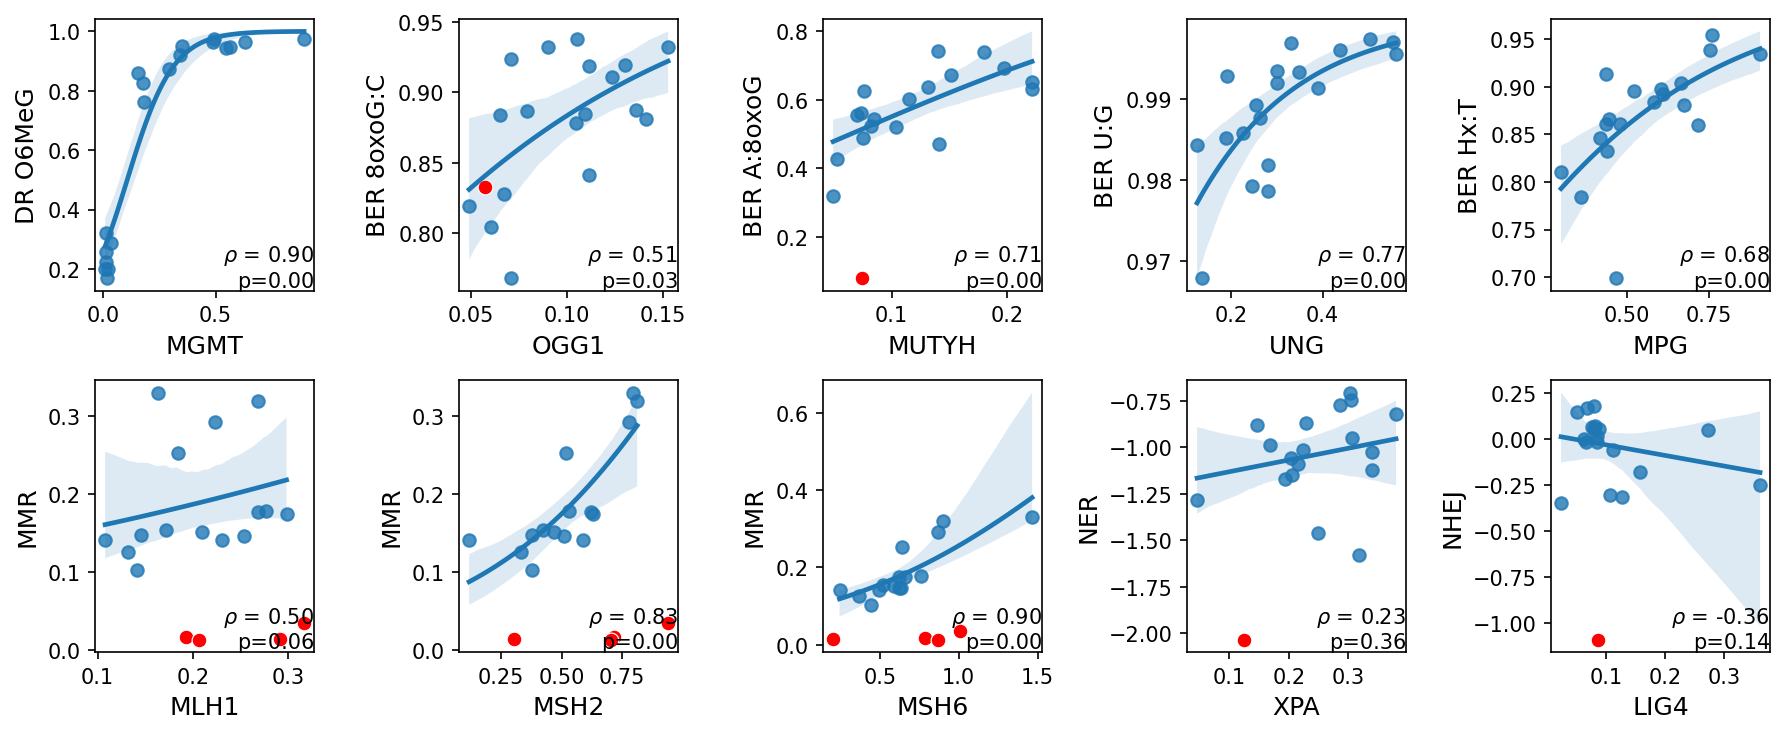

In [5]:
pathways = ['DR_O6MeG','BER_8oxoG_C','BER_A_8oxoG','BER_UG','BER_Hx','MMR','MMR','MMR','NER','NHEJ']
labels = ['DR O6MeG','BER 8oxoG:C','BER A:8oxoG','BER U:G','BER Hx:T','MMR','MMR','MMR','NER','NHEJ']

genes = ['MGMT','OGG1','MUTYH','UNG','MPG','MLH1','MSH2','MSH6','XPA','LIG4']
msi_lines = ['PF382','DND41','NALM6','JURKAT']
kos = [[],['U2OS'],['HAP1'],[],[],msi_lines,msi_lines,msi_lines,['HELA'],['TK6_ATCC']]


f,ax = plt.subplots(2,5,figsize=(12,5))
ax = ax.reshape(-1)

i=0
for g,p,l,ko in zip(genes,pathways,labels,kos):
    single_plot(df,
                gene=g,
                pathway=p,
                cl_ko = ko,
                ko_label = 'KO',
                wt_label = 'WT',
                pathway_label=l,
                logistic = (p not in ['NHEJ','NER']),
                legend=False,
                ax=ax[i])
    
    i+=1
plt.tight_layout()

plt.savefig("pdf/figure6a_repair_vs_expression.pdf")

## Figure 6b MSI vs MMR

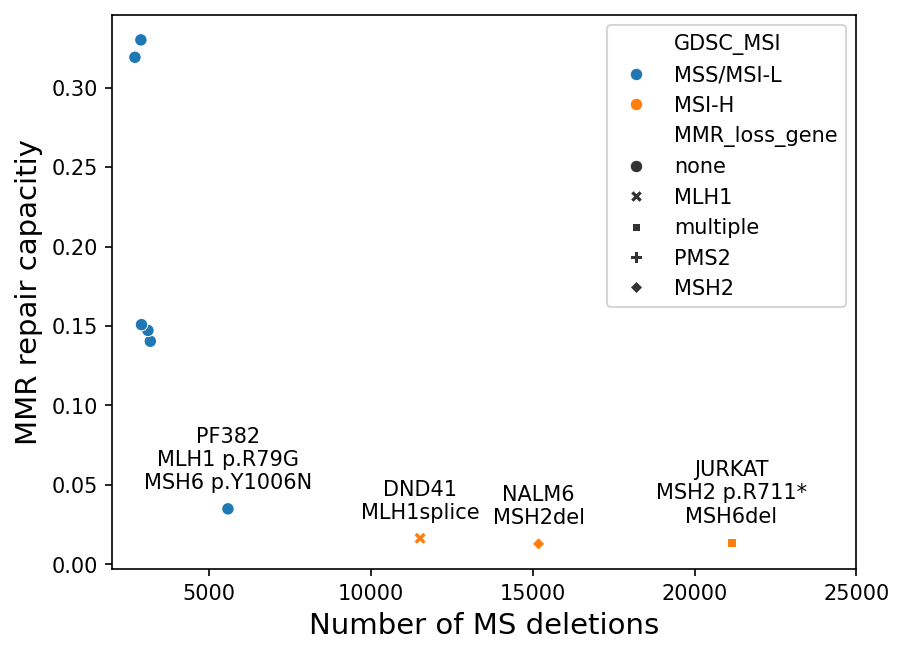

In [6]:
msi_data = pd.read_excel('../data/NIHMS1522798-supplement-Supp_Table_1.xlsx')
msi_data['stripped_name'] = msi_data['CCLE_ID'].str.replace('_.*','',regex=True)
df = get_repair_df(adata)
df = df[(df['timepoint']=='2h')&(df['pathway']=='MMR')]

df = df.join(msi_data.set_index('stripped_name'),on='cell_line',how='left')

# From DepMap.org
df['alteration'] = 'None'
df.loc[df['cell_line']=='NALM6','alteration'] = 'MSH2del'
df.loc[df['cell_line']=='JURKAT','alteration'] = 'MSH2 p.R711*\nMSH6del'
df.loc[df['cell_line']=='DND41','alteration'] = 'MLH1splice'
df.loc[df['cell_line']=='PF382','alteration'] = 'MLH1 p.R79G\nMSH6 p.Y1006N'

sns.scatterplot(x="ms_deletions_normed",
                y="repair",
                hue="GDSC_MSI",
                style='MMR_loss_gene',
                data=df)
plt.xlabel('Number of MS deletions',fontsize=14)
plt.ylabel('MMR repair capacitiy',fontsize=14)

plt.xlim([2000,25000])

for ind,row in df[df['alteration']!="None"].iterrows():
    plt.text(row["ms_deletions_normed"],
             row["repair"] + .01,
             row['cell_line'] + '\n' + row["alteration"],ha='center',va='bottom')
plt.savefig('pdf/figure6b_scrna_MSI_MMR_comparison.pdf',bbox_inches='tight')

In [7]:
idx = ~df['ms_deletions_normed'].isna()
spearmanr(df.loc[idx,'ms_deletions_normed'],df.loc[idx,'repair'])

SignificanceResult(statistic=np.float64(-0.8549450549450549), pvalue=np.float64(9.766040002967738e-05))

## Figure 6c

In [8]:
def annotate_cell_cycle(adata):
    cell_cycle_genes = np.unique(pd.read_csv('../data/regev_lab_cell_cycle_genes.txt',
                                                         header=None)[0])
    s_genes = cell_cycle_genes[:43]
    g2m_genes = cell_cycle_genes[43:]
                    
    cell_cycle_genes = [x for x in cell_cycle_genes if x in adata.var_names]

                            
    adata_cc = adata.copy()
    sc.pp.scale(adata_cc)

    sc.tl.score_genes_cell_cycle(adata_cc, s_genes=s_genes, g2m_genes=g2m_genes)

    adata.obs=adata_cc.obs
                                                
    return(adata)

In [9]:
adata = annotate_cell_cycle(adata)

/home/njharlen/anaconda3/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


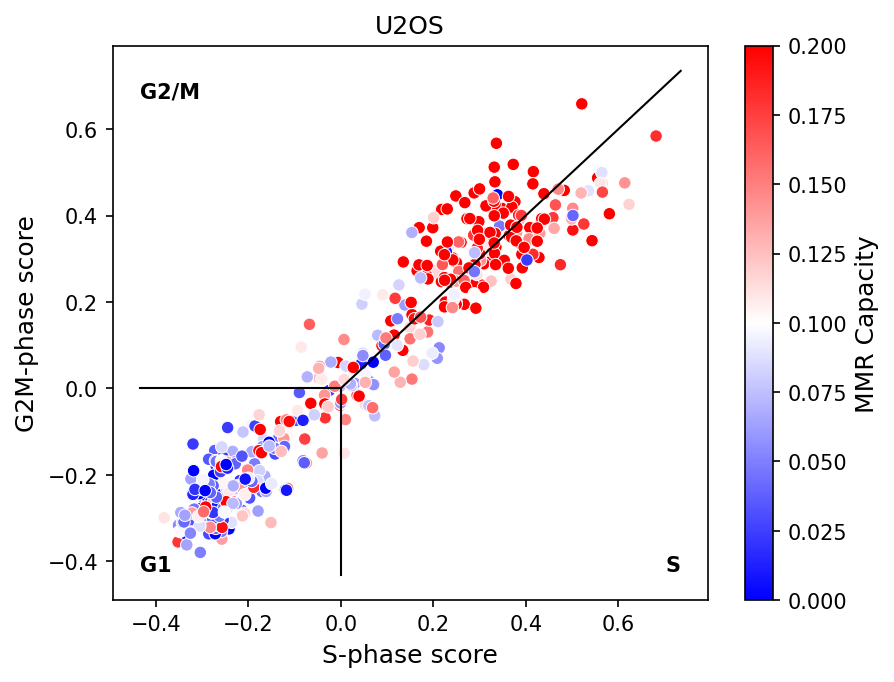

In [10]:
idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')&(adata.obs['cell_line']=='U2OS')

norm = plt.Normalize(0,.2)
sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)

sns.scatterplot(x="S_score",y="G2M_score",hue="MMR",data=adata.obs[idx],hue_norm=norm,palette="bwr")

plt.legend().remove()
g=plt.gcf().colorbar(sm,ax=plt.gca())
plt.xlabel('S-phase score',fontsize=12)
plt.ylabel('G2M-phase score',fontsize=12)

g.set_label('MMR Capacity',fontsize=12)


xl = plt.xlim()
yl = plt.ylim()
plt.plot([xl[0],0],[0,0],color='k',linewidth=1)
plt.plot([0,0],[yl[0],0],color='k',linewidth=1)
plt.plot([0,xl[1]],[0,xl[1]],color='k',linewidth=1)

plt.text(xl[0],yl[0],'G1',ha='left',va='bottom',fontweight='bold')
plt.text(xl[1],yl[0],'S',ha='right',va='bottom',fontweight='bold')
plt.text(xl[0],yl[1],'G2/M',ha='left',va='top',fontweight='bold')


plt.title('U2OS')

plt.savefig('pdf/figure6c_U2OS_cell_cycle_correlation.pdf',bbox_inches='tight')

In [11]:
idx1 = idx & (adata.obs['phase']=='G1')
idx2 = idx & (adata.obs['phase'].isin(['S','G2M']))

ranksums(adata.obs.loc[idx1,'MMR'],adata.obs.loc[idx2,'MMR'])

RanksumsResult(statistic=np.float64(-11.73751586920421), pvalue=np.float64(8.185552848587343e-32))

## Figure 6d

/tmp/ipykernel_171094/1382620820.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = adata.obs[idx].groupby(['cell_line','cycling_subset'])['MMR'].mean().reset_index()
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):


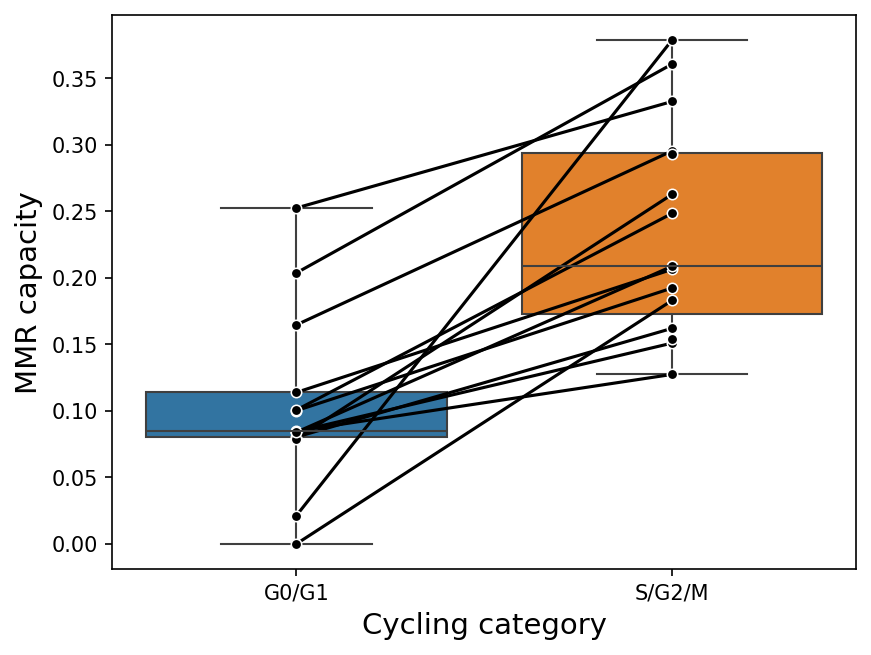

In [12]:
idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')&(~adata.obs['cell_line'].isin(msi_lines))

adata.obs['cycling_subset'] = adata.obs['phase'].isin(['G2M','S']).map({False : 'G0/G1',True : 'S/G2/M'})


x = adata.obs[idx].groupby(['cell_line','cycling_subset'])['MMR'].mean().reset_index()
sns.boxplot(x="cycling_subset",hue="cycling_subset",y="MMR",data=x,whis=100)
sns.lineplot(x="cycling_subset",y="MMR",units='cell_line',data=x,color='k',estimator=None,marker='o',markersize=5)
plt.ylabel('MMR capacity',fontsize=14)
plt.xlabel('Cycling category',fontsize=14)

plt.savefig('pdf/figure6dg_overall_cell_cycle_boxplots.pdf',bbox_inches='tight')

## Figure 6e - BER deletions

/tmp/ipykernel_171094/552195723.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['label'] = adata.obs['cell_line'].replace({'TK6_ATCC' : 'TK6 LIG4-/-','HELA' : 'HELA XPA-/-','U2OS' : 'U2OS OGG-/-','HAP1' : 'HAP1 MUTYH-/-'})
/tmp/ipykernel_171094/552195723.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata[idx].obs.groupby(['label','timepoint','condition'])[['GFP_BAR_007','BER_del']].sum()
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a fu

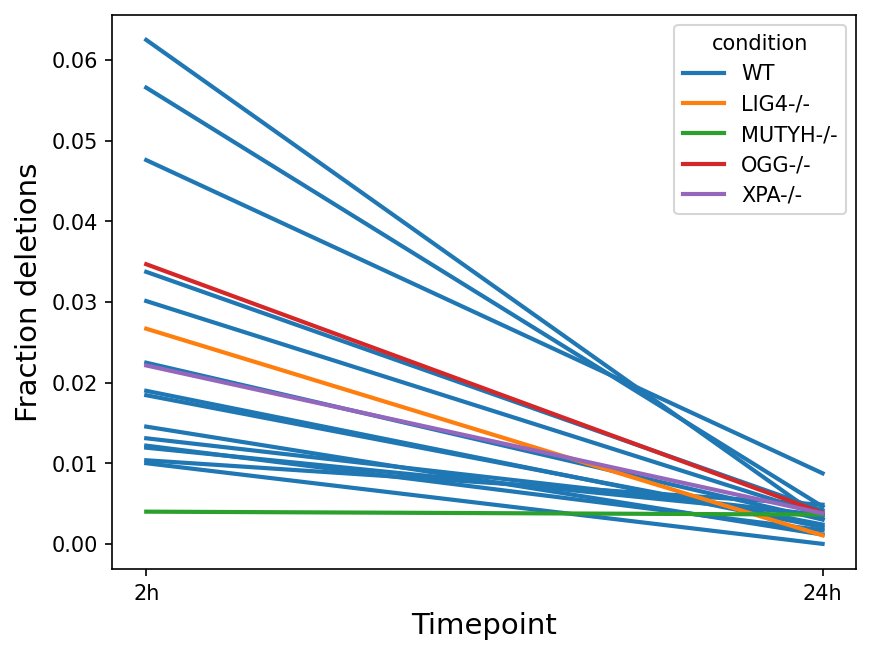

In [13]:
adata.obs['label'] = adata.obs['cell_line'].replace({'TK6_ATCC' : 'TK6 LIG4-/-','HELA' : 'HELA XPA-/-','U2OS' : 'U2OS OGG-/-','HAP1' : 'HAP1 MUTYH-/-'})


adata.obs['BER_del'] = adata.obsm['del_counts']['GFP_BAR_007']
adata.obs['condition'] = adata.obs['label'].str.split(' ',expand=True)[1].replace({None:'WT'})

adata.obs['condition'] = pd.Categorical(adata.obs['condition'],categories=['WT','LIG4-/-','MUTYH-/-','OGG-/-','XPA-/-'])

idx = adata.obs['transfected']
df = adata[idx].obs.groupby(['label','timepoint','condition'])[['GFP_BAR_007','BER_del']].sum()
df['f_del'] = df['BER_del']/df['GFP_BAR_007']

sns.lineplot(x='timepoint',y='f_del',data=df,hue="condition",linewidth=2,units='label',estimator=None)
plt.ylabel('Fraction deletions',fontsize=14)
plt.xlabel('Timepoint',fontsize=14)

plt.savefig('pdf/figure6e_scrna_ber_deletions.pdf',bbox_inches='tight')

## Supplementary Figure 11e

/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
/home/njharlen/anaconda3/lib/python3.10/site-packages/seaborn/relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ad

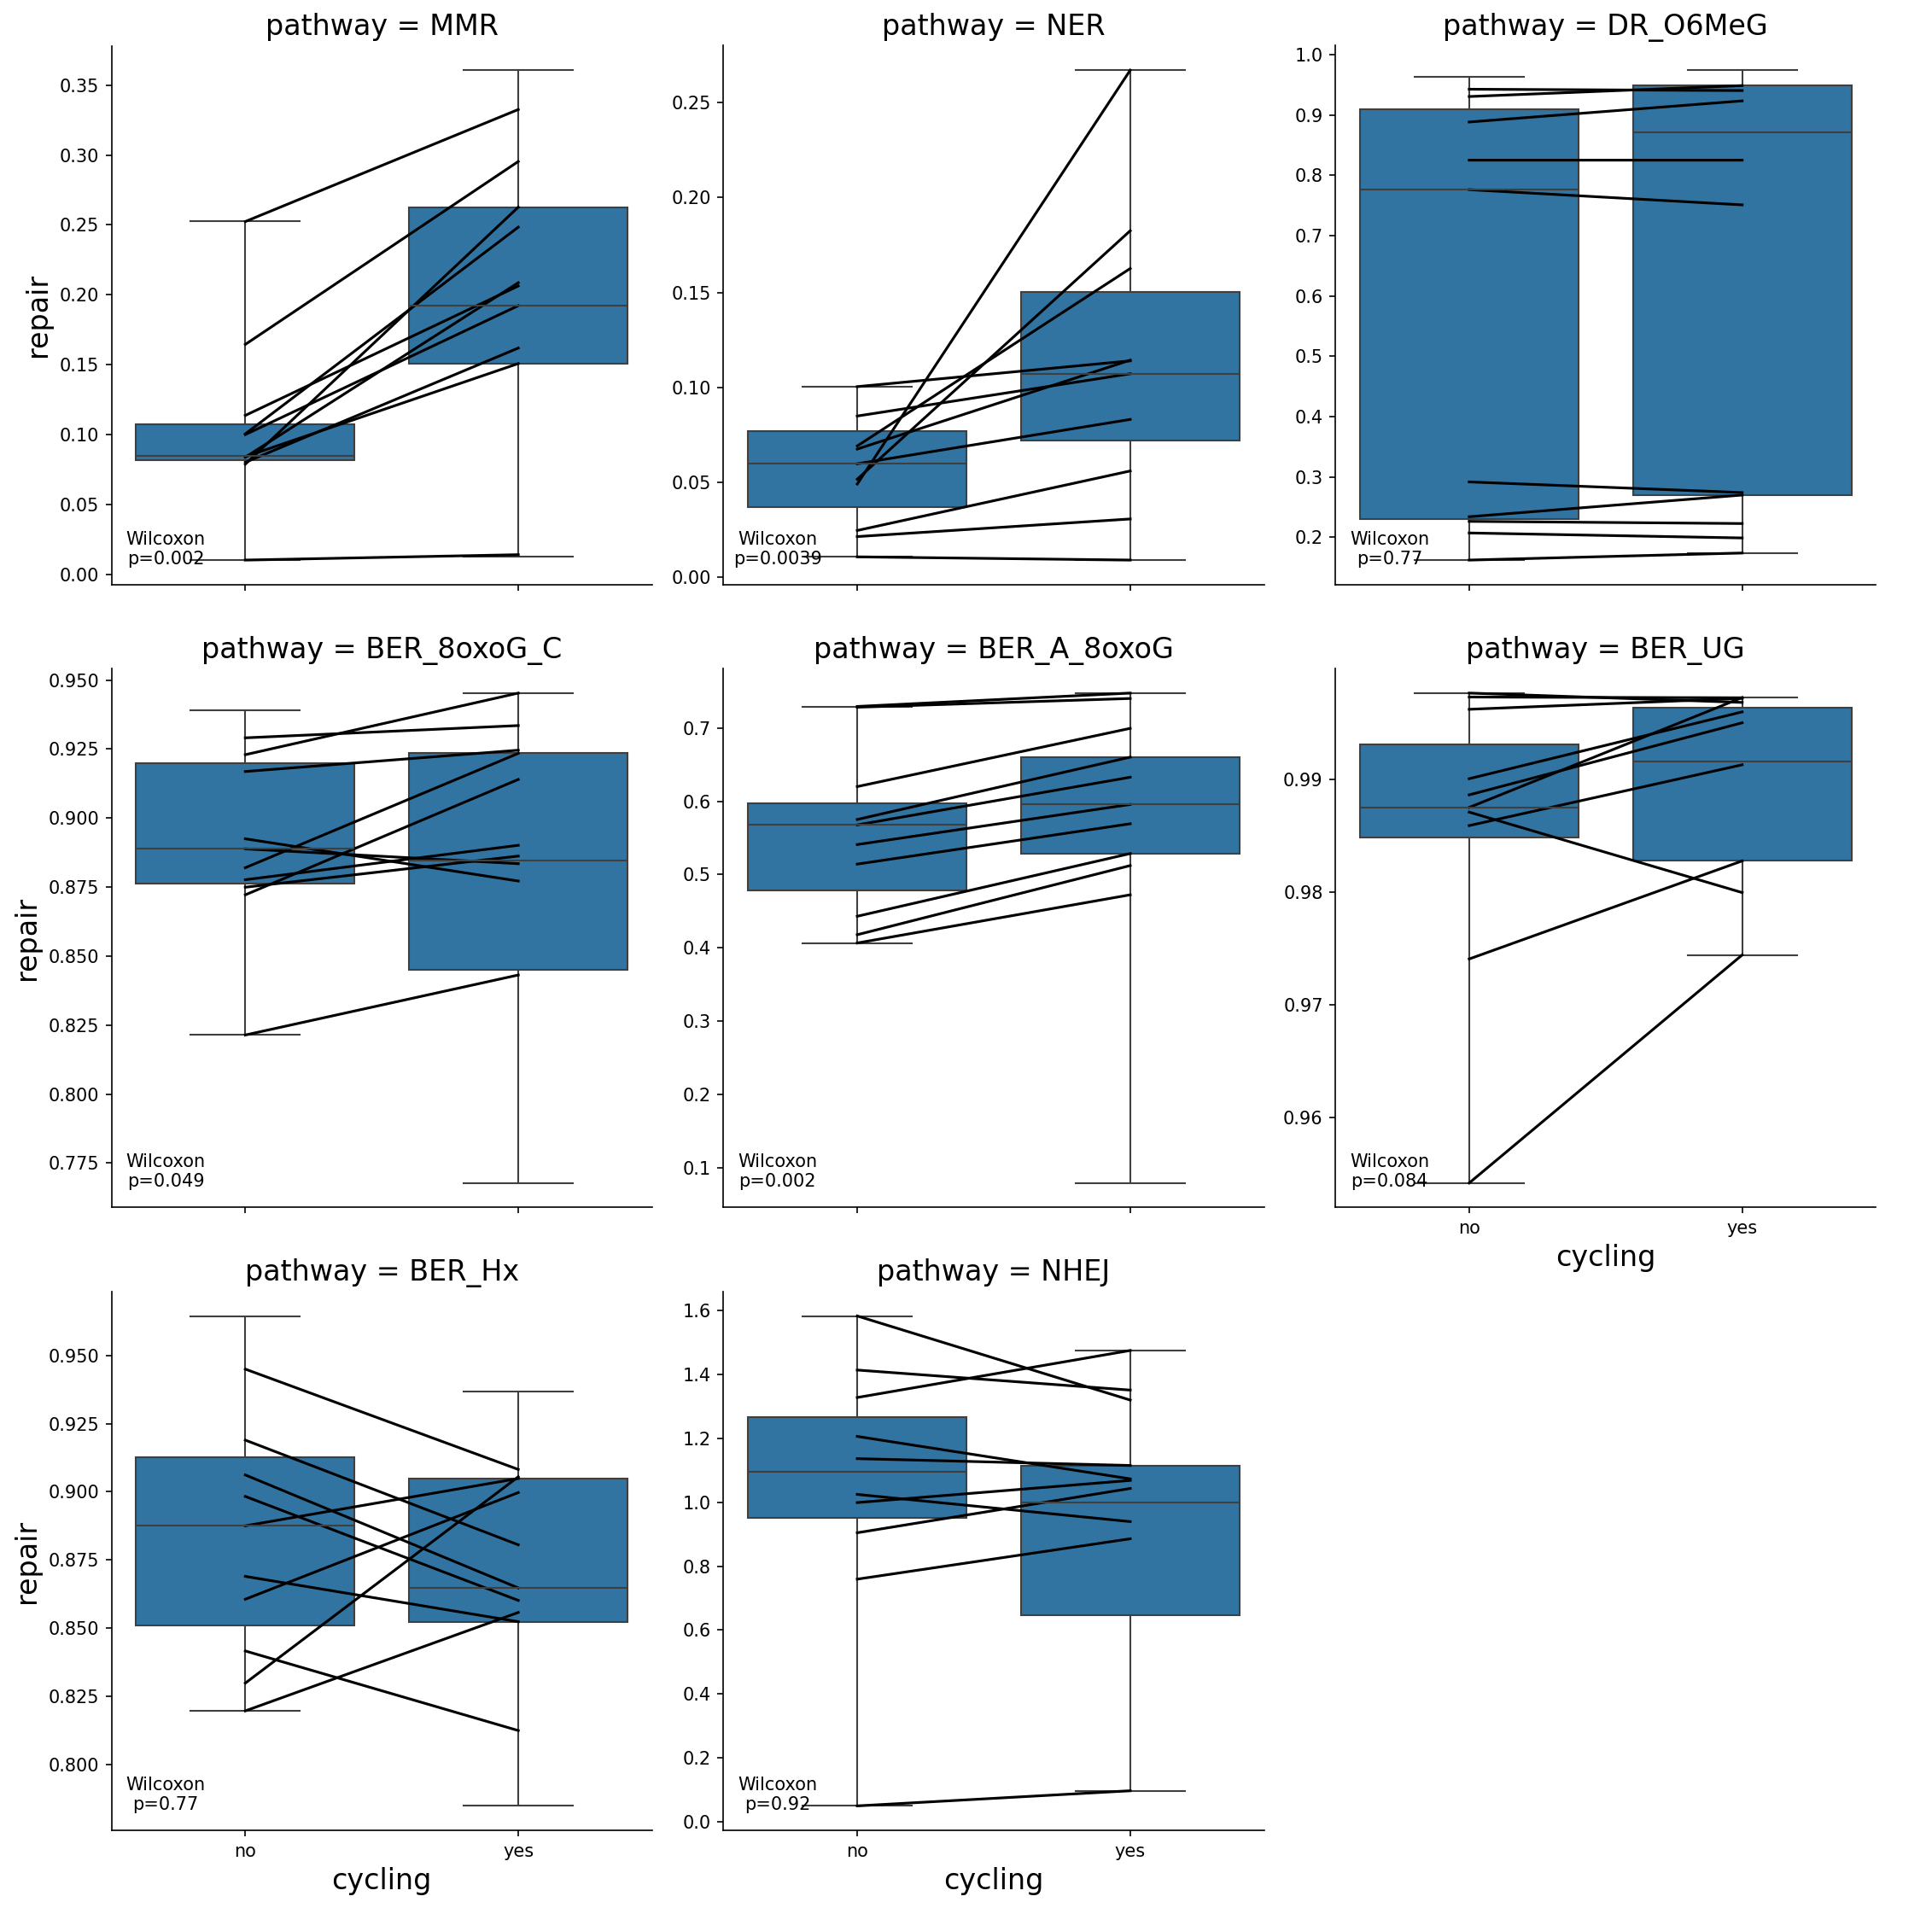

In [14]:

from scipy import stats

def cc_boxplot(adata,pathway,timepoint='2h'):
    idx = adata.obs['transfected']&(adata.obs['timepoint']==timepoint)

    x = get_repair_df(adata[idx],groupby=['cell_line','cycling'])
    x = x[x['n']>=10]

    x = x[x['pathway']==pathway]

    sns.boxplot(x="cycling",hue="cycling",y=pathway,data=x,whis=100)
    sns.lineplot(x="cycling",y="MMR",units='cell_line',data=x,color='k',estimator=None)


def annotate_wilcoxon(data, x, y, units, **kws):
    ax = plt.gca()
    
    # specific to your data: 'cycling' contains the two groups to compare
    groups = data[x].unique()
    
    # We need exactly 2 groups for a Wilcoxon test
    if len(groups) == 2:
        # Pivot data to wide-form to ensure we strictly match pairs by 'cell_line' (units)
        # dropna() ensures we only test complete pairs
        wide_df = data.pivot(index=units, columns=x, values=y).dropna()
        
        # Perform the test if we still have data after matching pairs
        if not wide_df.empty:
            stat, pval = stats.wilcoxon(wide_df[groups[0]], wide_df[groups[1]])
            
            # Annotate plot - adjusting y position (0.95) as needed
            ax.text(0.1, 0.1, f'Wilcoxon\np={pval:.2g}', 
                    transform=ax.transAxes, ha='center', va='top', fontsize=10)


adata.obs['cycling'] = adata.obs['phase'].isin(['G2M','S']).map({True : 'yes',False : 'no'})

idx = adata.obs['transfected']&(adata.obs['timepoint']=='2h')

df = get_repair_df(adata[idx],groupby=['cell_line','cycling'])
df = df[df['n']>=10]

g = sns.catplot(x="cycling",y="repair",col='pathway',data=df,sharey=False,kind='box',col_wrap=3,whis=100)
g.map_dataframe(sns.lineplot,x="cycling",
    y="repair",units="cell_line",estimator=None,color='k')

g.map_dataframe(annotate_wilcoxon, x="cycling", y="repair", units="cell_line")

plt.savefig('pdf/supplementary_figure11e_scrna_cell_cycle_plots.pdf',bbox_inches='tight')
